In [1]:
import numpy as np
import matplotlib.pyplot as plt

def run_adaptive_queue_simulation(J, m, lambda_val=8.0, mu_1=9.0, mu_2=18.0, N=100000):
    """
    Run a queue simulation with two servers and a finite buffer with adaptive service rates.

    Parameters:
    - J: Buffer size
    - m: Threshold for switching service rates (elements in system)
    - lambda_val: Arrival rate (clients/second)
    - mu_1: Slower service rate (clients/second)
    - mu_2: Faster service rate (clients/second)
    - N: Number of arrival attempts to simulate

    Returns:
    - avg_time_in_system: Average time packets spend in the system
    - rejection_probability: Probability a packet is rejected
    - t_mu1: Time spent at service rate mu_1
    - t_mu2: Time spent at service rate mu_2
    """
    # Variables
    t = 0
    server_1_state = 0
    server_2_state = 0
    t_arrival = np.random.exponential(1/lambda_val)
    t_departure_1 = float('inf')
    t_departure_2 = float('inf')
    num_in_system = 0
    num_in_queue = 0
    arr = 0
    dep = 0
    rj = 0

    # Arrays to store data
    arrival_times = []
    departure_times = []
    time_in_system = []

    # New variables to track time spent at each service rate
    t_mu1 = 0  # Time spent at service rate mu_1
    t_mu2 = 0  # Time spent at service rate mu_2

    # Helper function to determine current service rate
    def get_service_rate():
        return mu_2 if num_in_system >= m else mu_1

    # Simulation loop - run until N arrival attempts (accepted + rejected)
    while arr + rj < N:
        # Determine the next event
        t_next = min(t_arrival, t_departure_1, t_departure_2)

        # Track time spent at current service rate
        time_increment = t_next - t
        if num_in_system >= m:
            t_mu2 += time_increment
        else:
            t_mu1 += time_increment

        # Update current time
        t = t_next

        if t == t_arrival:  # Arrival event
            # Generate next arrival
            t_arrival = t + np.random.exponential(1/lambda_val)

            # First try to place in server
            if server_1_state == 0 or server_2_state == 0:
                # At least one server is idle, accept the packet
                arrival_times.append(t)
                arr += 1
                num_in_system += 1

                # Get current service rate based on system state
                current_service_rate = get_service_rate()

                # If both servers are idle, pick one randomly
                if server_1_state == 0 and server_2_state == 0:
                    if np.random.rand() < 0.5:  # 50% chance for each server
                        server_1_state = 1
                        t_departure_1 = t + np.random.exponential(1/current_service_rate)
                    else:
                        server_2_state = 1
                        t_departure_2 = t + np.random.exponential(1/current_service_rate)
                # Otherwise use the available server
                elif server_1_state == 0:
                    server_1_state = 1
                    t_departure_1 = t + np.random.exponential(1/current_service_rate)
                else:
                    server_2_state = 1
                    t_departure_2 = t + np.random.exponential(1/current_service_rate)

                # After adding a packet, we might need to update the service rate for the other server
                if num_in_system == m and server_1_state == 1 and server_2_state == 1:
                    # Need to recalculate remaining service time for the other server
                    # Rescale based on remaining time and new service rate
                    if t_departure_1 < t_departure_2:
                        # Server 2 needs to be updated (has longer remaining time)
                        remaining_time = t_departure_2 - t
                        scaling_factor = mu_1 / mu_2  # Scale by ratio of rates
                        t_departure_2 = t + (remaining_time * scaling_factor)
                    else:
                        # Server 1 needs to be updated
                        remaining_time = t_departure_1 - t
                        scaling_factor = mu_1 / mu_2
                        t_departure_1 = t + (remaining_time * scaling_factor)
            # Otherwise try to place in buffer
            elif num_in_queue < J:
                # Buffer has space, accept the packet
                arrival_times.append(t)
                arr += 1
                num_in_system += 1
                num_in_queue += 1

                # Check if we've crossed the threshold for service rate
                if num_in_system == m:
                    # Recalculate departure times for both servers
                    if server_1_state == 1:
                        remaining_time = t_departure_1 - t
                        scaling_factor = mu_1 / mu_2
                        t_departure_1 = t + (remaining_time * scaling_factor)

                    if server_2_state == 1:
                        remaining_time = t_departure_2 - t
                        scaling_factor = mu_1 / mu_2
                        t_departure_2 = t + (remaining_time * scaling_factor)
            else:
                # Both servers busy and buffer full, reject packet
                rj += 1

        elif t == t_departure_1:  # Departure from server 1
            # Process departure
            dep += 1
            departure_times.append(t)
            time_in_system.append(t - arrival_times[dep-1])
            num_in_system -= 1
            server_1_state = 0

            # Check if we've crossed below the threshold for service rate
            crossed_threshold = (num_in_system == m - 1)

            # Check if queue has packets waiting
            if num_in_queue > 0:
                num_in_queue -= 1
                server_1_state = 1

                # Get current service rate
                current_service_rate = get_service_rate()
                t_departure_1 = t + np.random.exponential(1/current_service_rate)

                # If we crossed below threshold, need to update the other server's departure time
                if crossed_threshold and server_2_state == 1:
                    remaining_time = t_departure_2 - t
                    scaling_factor = mu_2 / mu_1  # Reverse scaling (faster to slower)
                    t_departure_2 = t + (remaining_time * scaling_factor)
            else:
                t_departure_1 = float('inf')

                # If we crossed below threshold, need to update the other server's departure time
                if crossed_threshold and server_2_state == 1:
                    remaining_time = t_departure_2 - t
                    scaling_factor = mu_2 / mu_1
                    t_departure_2 = t + (remaining_time * scaling_factor)

        elif t == t_departure_2:  # Departure from server 2
            # Process departure
            dep += 1
            departure_times.append(t)
            time_in_system.append(t - arrival_times[dep-1])
            num_in_system -= 1
            server_2_state = 0

            # Check if we've crossed below the threshold for service rate
            crossed_threshold = (num_in_system == m - 1)

            # Check if queue has packets waiting
            if num_in_queue > 0:
                num_in_queue -= 1
                server_2_state = 1

                # Get current service rate
                current_service_rate = get_service_rate()
                t_departure_2 = t + np.random.exponential(1/current_service_rate)

                # If we crossed below threshold, need to update the other server's departure time
                if crossed_threshold and server_1_state == 1:
                    remaining_time = t_departure_1 - t
                    scaling_factor = mu_2 / mu_1
                    t_departure_1 = t + (remaining_time * scaling_factor)
            else:
                t_departure_2 = float('inf')

                # If we crossed below threshold, need to update the other server's departure time
                if crossed_threshold and server_1_state == 1:
                    remaining_time = t_departure_1 - t
                    scaling_factor = mu_2 / mu_1
                    t_departure_1 = t + (remaining_time * scaling_factor)

    # Calculate performance metrics
    if len(time_in_system) > 0:
        avg_time_in_system = np.mean(time_in_system)
    else:
        avg_time_in_system = 0

    rejection_probability = rj / (arr + rj)
    return avg_time_in_system, rejection_probability, t_mu1, t_mu2



In [2]:
def run_adaptive_queue_simulations(J, m, lambda_val=8.0, mu_1=9.0, mu_2=18.0, N=100000):
    """
    Run a queue simulation with two servers and a finite buffer with adaptive service rates.

    Args:
    - J: Buffer size
    - m: Threshold for switching service rates (elements in system)
    - lambda_val: Arrival rate (clients/second)
    - mu_1: Slower service rate (clients/second)
    - mu_2: Faster service rate (clients/second)
    - N: Number of arrival attempts to simulate

    Returns:
    - avg_time_in_system: Average time packets spend in the system
    - rejection_probability: Probability a packet is rejected
    - t_mu1: Time spent at service rate mu_1
    - t_mu2: Time spent at service rate mu_2
    - throughput: Average throughput (completed jobs per time unit)
    - avg_num_in_system: Average number of clients in system (E[q])
    - avg_time_in_queue: Average time spent in queue (E[tw])
    - avg_num_in_queue: Average number of clients in queue (E[w])
    """
    # Variables
    t = 0
    server_1_state = 0
    server_2_state = 0
    t_arrival = np.random.exponential(1/lambda_val)
    t_departure_1 = float('inf')
    t_departure_2 = float('inf')
    num_in_system = 0
    num_in_queue = 0
    arr = 0
    dep = 0
    rj = 0

    # Arrays to store data
    arrival_times = []
    departure_times = []
    time_in_system = []
    queue_entry_times = []       # When each client enters the queue
    service_entry_times = []     # When each client leaves queue to enter service
    time_in_queue = []           # Time spent in queue for each client

    # Variables for calculating time averages
    last_event_time = 0
    area_num_in_system = 0       # For E[q]
    area_num_in_queue = 0        # For E[w]

    # New variables to track time spent at each service rate
    t_mu1 = 0  # Time spent at service rate mu_1
    t_mu2 = 0  # Time spent at service rate mu_2

    # Helper function to determine current service rate
    def get_service_rate():
        return mu_2 if num_in_system >= m else mu_1

    # Simulation loop - run until N arrival attempts (accepted + rejected)
    while arr + rj < N:
        # Determine the next event
        t_next = min(t_arrival, t_departure_1, t_departure_2)

        # Update areas for time averages before advancing time
        time_increment = t_next - t
        area_num_in_system += num_in_system * time_increment
        area_num_in_queue += num_in_queue * time_increment

        # Track time spent at current service rate
        if num_in_system >= m:
            t_mu2 += time_increment
        else:
            t_mu1 += time_increment

        # Update current time
        t = t_next

        if t == t_arrival:  # Arrival event
            # Generate next arrival
            t_arrival = t + np.random.exponential(1/lambda_val)

            # First try to place in server
            if server_1_state == 0 or server_2_state == 0:
                # At least one server is idle, accept the packet
                arrival_times.append(t)
                arr += 1
                num_in_system += 1

                # Get current service rate based on system state
                current_service_rate = get_service_rate()

                # If both servers are idle, pick one randomly
                if server_1_state == 0 and server_2_state == 0:
                    if np.random.rand() < 0.5:  # 50% chance for each server
                        server_1_state = 1
                        t_departure_1 = t + np.random.exponential(1/current_service_rate)
                    else:
                        server_2_state = 1
                        t_departure_2 = t + np.random.exponential(1/current_service_rate)
                # Otherwise use the available server
                elif server_1_state == 0:
                    server_1_state = 1
                    t_departure_1 = t + np.random.exponential(1/current_service_rate)
                else:
                    server_2_state = 1
                    t_departure_2 = t + np.random.exponential(1/current_service_rate)

                # Direct service (no queue time)
                service_entry_times.append(t)
                time_in_queue.append(0)  # No queue time

                # After adding a packet, we might need to update the service rate for the other server
                if num_in_system == m and server_1_state == 1 and server_2_state == 1:
                    # Need to recalculate remaining service time for the other server
                    # Rescale based on remaining time and new service rate
                    if t_departure_1 < t_departure_2:
                        # Server 2 needs to be updated (has longer remaining time)
                        remaining_time = t_departure_2 - t
                        scaling_factor = mu_1 / mu_2  # Scale by ratio of rates
                        t_departure_2 = t + (remaining_time * scaling_factor)
                    else:
                        # Server 1 needs to be updated
                        remaining_time = t_departure_1 - t
                        scaling_factor = mu_1 / mu_2
                        t_departure_1 = t + (remaining_time * scaling_factor)
            # Otherwise try to place in buffer
            elif num_in_queue < J:
                # Buffer has space, accept the packet
                arrival_times.append(t)
                queue_entry_times.append(t)  # Record time entering queue
                arr += 1
                num_in_system += 1
                num_in_queue += 1

                # Check if we've crossed the threshold for service rate
                if num_in_system == m:
                    # Recalculate departure times for both servers
                    if server_1_state == 1:
                        remaining_time = t_departure_1 - t
                        scaling_factor = mu_1 / mu_2
                        t_departure_1 = t + (remaining_time * scaling_factor)

                    if server_2_state == 1:
                        remaining_time = t_departure_2 - t
                        scaling_factor = mu_1 / mu_2
                        t_departure_2 = t + (remaining_time * scaling_factor)
            else:
                # Both servers busy and buffer full, reject packet
                rj += 1

        elif t == t_departure_1:  # Departure from server 1
            # Process departure
            dep += 1
            departure_times.append(t)
            time_in_system.append(t - arrival_times[dep-1])
            num_in_system -= 1
            server_1_state = 0

            # Check if we've crossed below the threshold for service rate
            crossed_threshold = (num_in_system == m - 1)

            # Check if queue has packets waiting
            if num_in_queue > 0:
                num_in_queue -= 1
                server_1_state = 1

                # Record service entry time and calculate queue time
                service_entry_times.append(t)
                queue_time = t - queue_entry_times.pop(0)  # First in, first out
                time_in_queue.append(queue_time)

                # Get current service rate
                current_service_rate = get_service_rate()
                t_departure_1 = t + np.random.exponential(1/current_service_rate)

                # If we crossed below threshold, need to update the other server's departure time
                if crossed_threshold and server_2_state == 1:
                    remaining_time = t_departure_2 - t
                    scaling_factor = mu_2 / mu_1  # Reverse scaling (faster to slower)
                    t_departure_2 = t + (remaining_time * scaling_factor)
            else:
                t_departure_1 = float('inf')

                # If we crossed below threshold, need to update the other server's departure time
                if crossed_threshold and server_2_state == 1:
                    remaining_time = t_departure_2 - t
                    scaling_factor = mu_2 / mu_1
                    t_departure_2 = t + (remaining_time * scaling_factor)

        elif t == t_departure_2:  # Departure from server 2
            # Process departure
            dep += 1
            departure_times.append(t)
            time_in_system.append(t - arrival_times[dep-1])
            num_in_system -= 1
            server_2_state = 0

            # Check if we've crossed below the threshold for service rate
            crossed_threshold = (num_in_system == m - 1)

            # Check if queue has packets waiting
            if num_in_queue > 0:
                num_in_queue -= 1
                server_2_state = 1

                # Record service entry time and calculate queue time
                service_entry_times.append(t)
                queue_time = t - queue_entry_times.pop(0)  # First in, first out
                time_in_queue.append(queue_time)

                # Get current service rate
                current_service_rate = get_service_rate()
                t_departure_2 = t + np.random.exponential(1/current_service_rate)

                # If we crossed below threshold, need to update the other server's departure time
                if crossed_threshold and server_1_state == 1:
                    remaining_time = t_departure_1 - t
                    scaling_factor = mu_2 / mu_1
                    t_departure_1 = t + (remaining_time * scaling_factor)
            else:
                t_departure_2 = float('inf')

                # If we crossed below threshold, need to update the other server's departure time
                if crossed_threshold and server_1_state == 1:
                    remaining_time = t_departure_1 - t
                    scaling_factor = mu_2 / mu_1
                    t_departure_1 = t + (remaining_time * scaling_factor)

    # Calculate performance metrics
    if len(time_in_system) > 0:
        avg_time_in_system = np.mean(time_in_system)
    else:
        avg_time_in_system = 0

    # Calculate average time in queue
    if len(time_in_queue) > 0:
        avg_time_in_queue = np.mean(time_in_queue)
    else:
        avg_time_in_queue = 0

    # Calculate time-average number of clients in system and queue
    simulation_time = t
    avg_num_in_system = area_num_in_system / simulation_time  # E[q]
    avg_num_in_queue = area_num_in_queue / simulation_time    # E[w]

    # Calculate rejection probability
    rejection_probability = rj / (arr + rj)

    # Calculate average throughput based on departure times
    if len(departure_times) > 1:
        # Número total de pacotes completados dividido pelo tempo total
        simulation_time = departure_times[-1]
        throughput = dep / simulation_time
    else:
        throughput = 0

    return avg_time_in_system, rejection_probability, t_mu1, t_mu2, throughput, avg_num_in_system, avg_time_in_queue, avg_num_in_queue


Values test

In [9]:
# Parâmetros fixos
J = 30
m = 15
mu_1 = 10.0
mu_2 = 20.0
N = 100000
lamda=35

# Função para formatar resultados
def format_results(name, results):
    avg_time, rej_prob, t_mu1, t_mu2, throughput, avg_num, avg_q_time, avg_q_num = results

    print(f"\n{name}:")
    print(f"Tempo médio no sistema (E[t]): {avg_time:.4f}")
    print(f"Probabilidade de rejeição: {rej_prob:.4f} ({rej_prob*100:.2f}%)")
    print(f"Tempo em μ₁: {t_mu1:.2f}, Tempo em μ₂: {t_mu2:.2f} (Fração μ₂: {t_mu2/(t_mu1+t_mu2):.2f})")
    print(f"Throughput médio: {throughput:.4f}")
    print(f"Número médio no sistema (E[q]): {avg_num:.4f}")
    print(f"Tempo médio na fila (E[tw]): {avg_q_time:.4f}")
    print(f"Número médio na fila (E[w]): {avg_q_num:.4f}")

    # Verifica Lei de Little (E[q] ≈ λ(1-Pᵣ)E[t])
    lambda_eff = throughput
    little_check = lambda_eff * avg_time
    print(f"Verificação Lei de Little: E[q]={avg_num:.4f}, λ(1-Pᵣ)E[t]={little_check:.4f}")

print("SIMULAÇÃO DE FILA ADAPTATIVA - COMPARAÇÃO DE CASOS PARA λ="+str(lamda))



results_adaptive_15 = run_adaptive_queue_simulations(
    J=J, m=m, lambda_val=lamda, mu_1=mu_1, mu_2=mu_2, N=N)
format_results("Sistema Adaptativo (μ₁=10, μ₂=20, m=5)", results_adaptive_15)

# Caso não-adaptativo (apenas μ₁)
results_only_mu1_15 = run_adaptive_queue_simulations(
    J=J, m=1000, lambda_val=lamda, mu_1=mu_1, mu_2=mu_1, N=N)  # m grande para nunca adaptar
format_results("Sistema Não-Adaptativo (apenas μ₁=10)", results_only_mu1_15)

# Caso não-adaptativo (apenas μ₂)
results_only_mu2_15 = run_adaptive_queue_simulations(
    J=J, m=0, lambda_val=lamda, mu_1=mu_2, mu_2=mu_2, N=N)  # m=0 para sempre usar μ₂
format_results("Sistema Não-Adaptativo (apenas μ₂=20)", results_only_mu2_15)
print("\n SIMULAÇÃO ENERGETICA")
# Para λ=15
t_mu1_15, t_mu2_15 = results_adaptive_15[2], results_adaptive_15[3]
total_time_15 = t_mu1_15 + t_mu2_15
energy_adaptive_15 = (t_mu1_15 * 1.0 + t_mu2_15 * 2.0) / total_time_15
energy_only_mu1_15 = 1.0  # Energia normalizada
energy_only_mu2_15 = 2.0  # Energia normalizada

print(f"Consumo médio de energia - Adaptativo: {energy_adaptive_15:.4f}")
print(f"Consumo médio de energia - Apenas μ₁: {energy_only_mu1_15:.4f}")
print(f"Consumo médio de energia - Apenas μ₂: {energy_only_mu2_15:.4f}")
print(f"Economia vs. Apenas μ₂: {(1 - energy_adaptive_15/energy_only_mu2_15)*100:.2f}%")


SIMULAÇÃO DE FILA ADAPTATIVA - COMPARAÇÃO DE CASOS PARA λ=35

Sistema Adaptativo (μ₁=10, μ₂=20, m=5):
Tempo médio no sistema (E[t]): 0.5280
Probabilidade de rejeição: 0.0109 (1.09%)
Tempo em μ₁: 748.72, Tempo em μ₂: 2108.04 (Fração μ₂: 0.74)
Throughput médio: 34.6179
Número médio no sistema (E[q]): 18.2803
Tempo médio na fila (E[tw]): 0.4703
Número médio na fila (E[w]): 16.2805
Verificação Lei de Little: E[q]=18.2803, λ(1-Pᵣ)E[t]=18.2794

Sistema Não-Adaptativo (apenas μ₁=10):
Tempo médio no sistema (E[t]): 1.5306
Probabilidade de rejeição: 0.4281 (42.81%)
Tempo em μ₁: 2854.66, Tempo em μ₂: 0.00 (Fração μ₂: 0.00)
Throughput médio: 20.0236
Número médio no sistema (E[q]): 30.6542
Tempo médio na fila (E[tw]): 1.4307
Número médio na fila (E[w]): 28.6543
Verificação Lei de Little: E[q]=30.6542, λ(1-Pᵣ)E[t]=30.6478

Sistema Não-Adaptativo (apenas μ₂=20):
Tempo médio no sistema (E[t]): 0.2002
Probabilidade de rejeição: 0.0020 (0.20%)
Tempo em μ₁: 0.00, Tempo em μ₂: 2861.28 (Fração μ₂: 1.00)
T

Buffer test

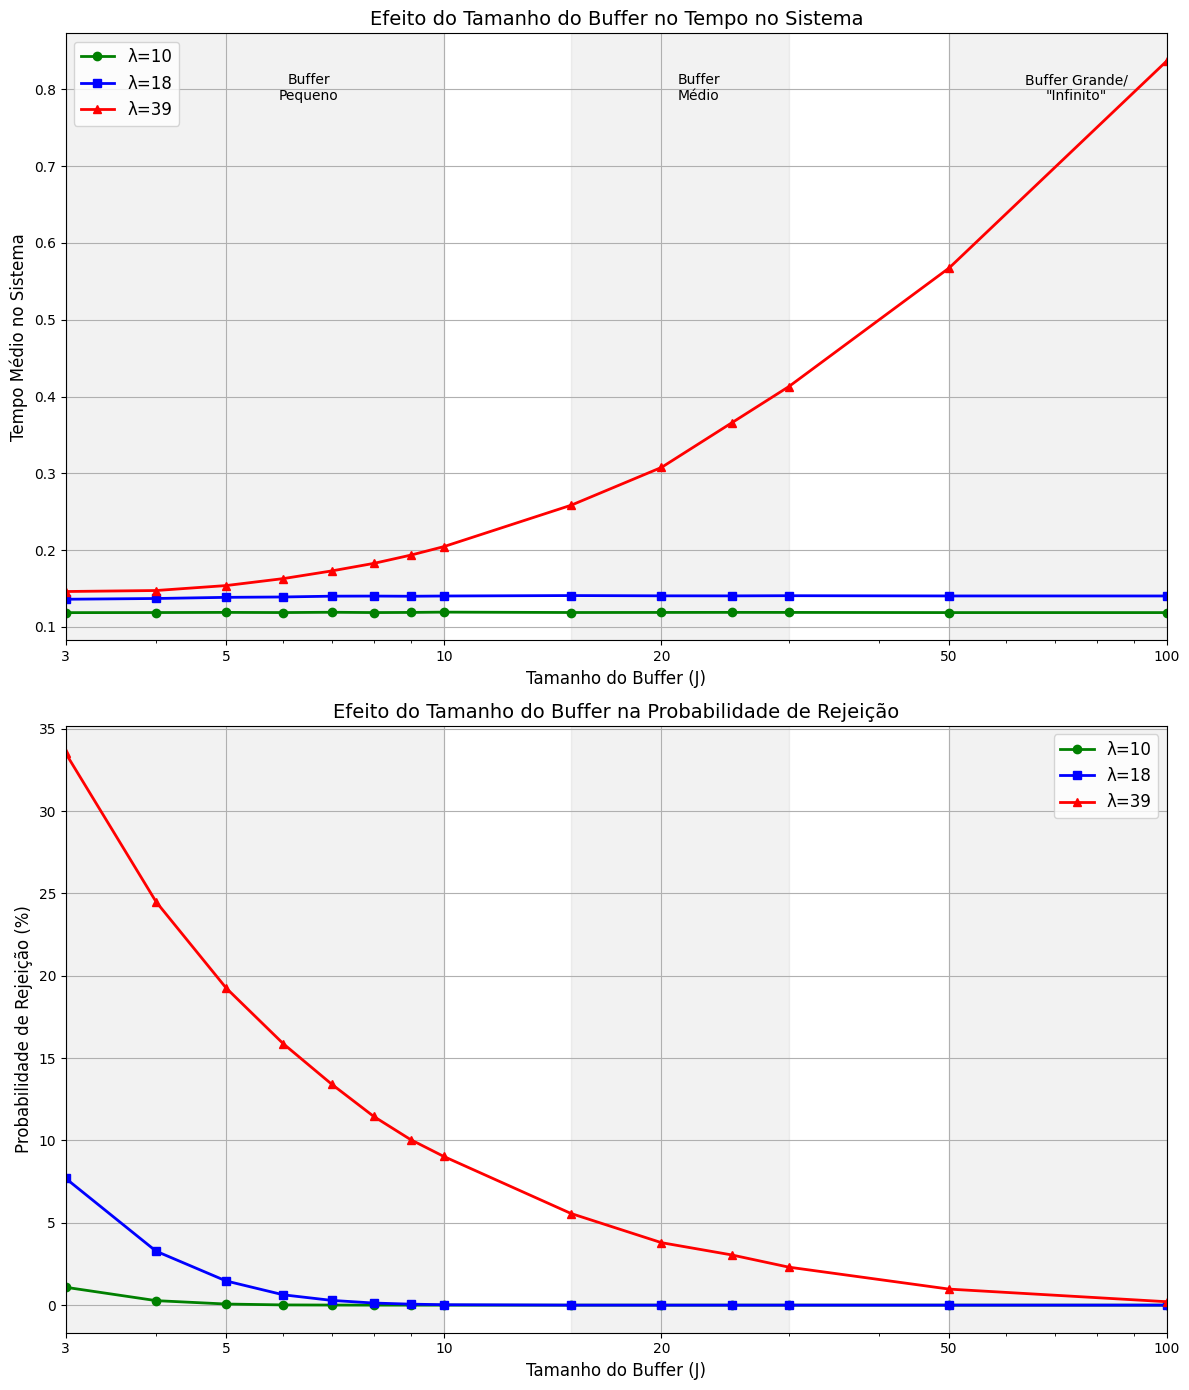

In [7]:
# Parâmetros fixos
mu_1 = 10.0           # Taxa de serviço base
mu_2 = 20.0           # Taxa de serviço aumentada (2x mais rápida)
m = 5                 # Limiar fixo para troca de velocidades
N = 1000000           # Número de tentativas de chegada

# Definir cenários de carga usando valores de lambda diretamente
lambda_baixo = 10    # Carga baixa
lambda_medio = 18    # Carga média
lambda_alto = 39     # Carga alta

# Faixas de tamanho de buffer
buffers_pequenos = list(range(3, 11))  # 3-10
buffers_medios = list(range(15, 31, 5))  # 15, 20, 25, 30
buffers_grandes = [50, 100]  # Aproximando-se de "infinito"

# Combinar todos os tamanhos de buffer para o gráfico
tamanhos_buffer = buffers_pequenos + buffers_medios + buffers_grandes

# Criar dois gráficos - um para tempo no sistema, outro para probabilidade de rejeição
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14))

# Configurar cores e marcadores para os cenários de carga
cenarios = [
    (lambda_baixo, "λ=10", "green", "o"),
    (lambda_medio, "λ=18", "blue", "s"),
    (lambda_alto, "λ=39", "red", "^")
]

# Executar simulações e coletar resultados
for lambda_val, label, cor, marcador in cenarios:
    tempos_medios = []
    probs_rej = []
    for J in tamanhos_buffer:
        #print(f"Simulando λ={lambda_val}, J={J}...")
        tempo_medio, prob_rej, _, _ = run_adaptive_queue_simulation(
            J=J, m=m, lambda_val=lambda_val, mu_1=mu_1, mu_2=mu_2, N=N)
        tempos_medios.append(tempo_medio)
        probs_rej.append(prob_rej * 100)  # Converter para porcentagem

    ax1.plot(tamanhos_buffer, tempos_medios, marker=marcador, color=cor, linestyle='-', label=label, linewidth=2)
    ax2.plot(tamanhos_buffer, probs_rej, marker=marcador, color=cor, linestyle='-', label=label, linewidth=2)

# Criar regiões verticais para separar visualmente as categorias de tamanho de buffer
regioes_buffer = [
    (min(buffers_pequenos), max(buffers_pequenos), "Buffer\nPequeno", 0.1),
    (min(buffers_medios), max(buffers_medios), "Buffer\nMédio", 0.1),
    (min(buffers_grandes), 100, "Buffer Grande/\n\"Infinito\"", 0.1)
]

for inicio, fim, rotulo_regiao, alpha in regioes_buffer:
    ax1.axvspan(inicio, fim, alpha=alpha, color='gray')
    ax1.text((inicio+fim)/2, ax1.get_ylim()[1]*0.9, rotulo_regiao,
             horizontalalignment='center', fontsize=10)
    ax2.axvspan(inicio, fim, alpha=alpha, color='gray')

# Formatar gráfico de tempo no sistema
ax1.set_xscale('log')
ax1.set_xlim(3, 100)  # Limitar eixo x até 100
ax1.set_xlabel('Tamanho do Buffer (J)', fontsize=12)
ax1.set_ylabel('Tempo Médio no Sistema', fontsize=12)
ax1.set_title('Efeito do Tamanho do Buffer no Tempo no Sistema', fontsize=14)
ax1.grid(True)
ax1.legend(fontsize=12)

# Deixar os ticks do eixo x mais claros com rótulos personalizados
x_ticks = [3, 5, 10, 20, 50, 100]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([str(x) for x in x_ticks], fontsize=10)

# Formatar gráfico de probabilidade de rejeição
ax2.set_xscale('log')
ax2.set_xlim(3, 100)  # Limitar eixo x até 100
ax2.set_xlabel('Tamanho do Buffer (J)', fontsize=12)
ax2.set_ylabel('Probabilidade de Rejeição (%)', fontsize=12)
ax2.set_title('Efeito do Tamanho do Buffer na Probabilidade de Rejeição', fontsize=14)
ax2.grid(True)
ax2.legend(fontsize=12)

# Deixar os ticks do eixo x mais claros com rótulos personalizados para o segundo gráfico também
ax2.set_xticks(x_ticks)
ax2.set_xticklabels([str(x) for x in x_ticks], fontsize=10)

plt.tight_layout()
plt.show()

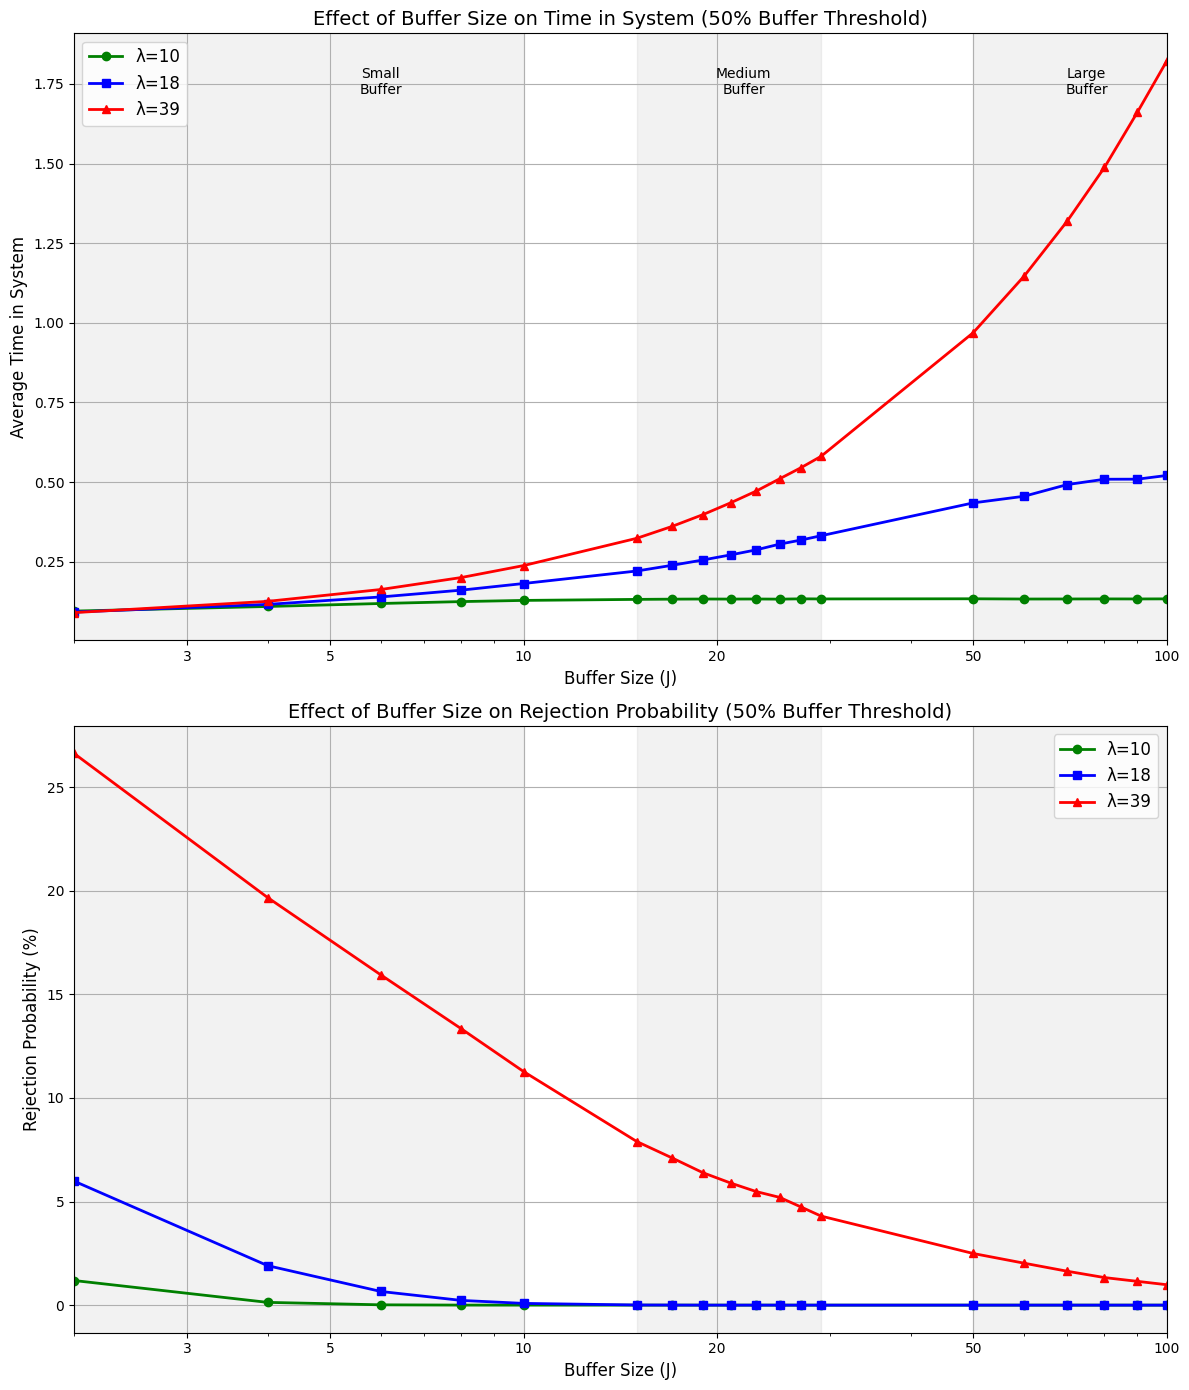

In [13]:
# Fixed parameters
mu_1 = 10.0           # Base service rate
mu_2 = 20.0           # Enhanced service rate (2x faster)
N = 1000000           # Number of arrival attempts

# Define load scenarios using lambda values directly
low_lambda = 10    # Low load
med_lambda = 18    # Medium load
high_lambda = 39   # High load

# Buffer size ranges
small_buffers = list(range(2, 11,2))  # 3-10
med_buffers = list(range(15, 31, 2))  # 15-30
large_buffers = list(range(50, 101, 10))  # 50-100
#large_buffers = [50, 100]  # 50-100

# Combine all buffer sizes for the plot
buffer_sizes = small_buffers + med_buffers + large_buffers

# Create two plots - one for time in system, one for rejection probability
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14))

# Set up colors and markers for the load scenarios
scenarios = [
    (low_lambda, "λ=10", "green", "o"),
    (med_lambda, "λ=18", "blue", "s"),
    (high_lambda, "λ=39", "red", "^")
]

# Run simulations and collect results
for lambda_val, label, color, marker in scenarios:
    avg_times = []
    rej_probs = []
    for J in buffer_sizes:
        # Calculate threshold as 2 (servers) + 50% of buffer
        m = 2 + int(0.5 * J)
        ##print(f"Simulating λ={lambda_val}, J={J}, m={m} (50% buffer threshold)...")
        avg_time, rej_prob, _, _ = run_adaptive_queue_simulation(
            J=J, m=m, lambda_val=lambda_val, mu_1=mu_1, mu_2=mu_2, N=N)
        avg_times.append(avg_time)
        rej_probs.append(rej_prob * 100)  # Convert to percentage

    ax1.plot(buffer_sizes, avg_times, marker=marker, color=color, linestyle='-', label=label, linewidth=2)
    ax2.plot(buffer_sizes, rej_probs, marker=marker, color=color, linestyle='-', label=label, linewidth=2)

# Create vertical regions to visually separate buffer size categories
buffer_regions = [
    (min(small_buffers), max(small_buffers), "Small\nBuffer", 0.1),
    (min(med_buffers), max(med_buffers), "Medium\nBuffer", 0.1),
    (min(large_buffers), max(large_buffers), "Large\nBuffer", 0.1)
]

for start, end, region_label, alpha in buffer_regions:
    ax1.axvspan(start, end, alpha=alpha, color='gray')
    ax1.text((start+end)/2, ax1.get_ylim()[1]*0.9, region_label,
             horizontalalignment='center', fontsize=10)
    ax2.axvspan(start, end, alpha=alpha, color='gray')

# Format time in system plot
ax1.set_xscale('log')
ax1.set_xlim(2, 100)  # Limit x-axis to 100
ax1.set_xlabel('Buffer Size (J)', fontsize=12)
ax1.set_ylabel('Average Time in System', fontsize=12)
ax1.set_title('Effect of Buffer Size on Time in System (50% Buffer Threshold)', fontsize=14)
ax1.grid(True)
ax1.legend(fontsize=12)

# Make x-axis ticks clearer with custom labels
x_ticks = [3, 5, 10, 20, 50, 100]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([str(x) for x in x_ticks], fontsize=10)

# Format rejection probability plot
ax2.set_xscale('log')
ax2.set_xlim(2, 100)  # Limit x-axis to 100
ax2.set_xlabel('Buffer Size (J)', fontsize=12)
ax2.set_ylabel('Rejection Probability (%)', fontsize=12)
ax2.set_title('Effect of Buffer Size on Rejection Probability (50% Buffer Threshold)', fontsize=14)
ax2.grid(True)
ax2.legend(fontsize=12)

# Make x-axis ticks clearer with custom labels for second plot too
ax2.set_xticks(x_ticks)
ax2.set_xticklabels([str(x) for x in x_ticks], fontsize=10)

plt.tight_layout()
plt.show()

Pruebas de redimiento

Running Pareto Frontier Analysis...
Analisando cenário 1: μ₂=12.5, λ=10.0 (80% de μ₂)
  m=2...
  m=3...
  m=4...
  m=5...
  m=6...
  m=7...
  m=8...
  m=9...
  m=10...


/tmp/ipython-input-7-2758445414.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[idx].legend(fontsize=10)


Analisando cenário 2: μ₂=15.0, λ=10.0 (80% de μ₂)
  m=2...
  m=3...
  m=4...
  m=5...
  m=6...
  m=7...
  m=8...
  m=9...
  m=10...


/tmp/ipython-input-7-2758445414.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[idx].legend(fontsize=10)


Analisando cenário 3: μ₂=17.5, λ=10.0 (80% de μ₂)
  m=2...
  m=3...
  m=4...
  m=5...
  m=6...
  m=7...
  m=8...
  m=9...
  m=10...


/tmp/ipython-input-7-2758445414.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[idx].legend(fontsize=10)


Analisando cenário 4: μ₂=20.0, λ=10.0 (80% de μ₂)
  m=2...
  m=3...
  m=4...
  m=5...
  m=6...
  m=7...
  m=8...
  m=9...
  m=10...


/tmp/ipython-input-7-2758445414.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[idx].legend(fontsize=10)


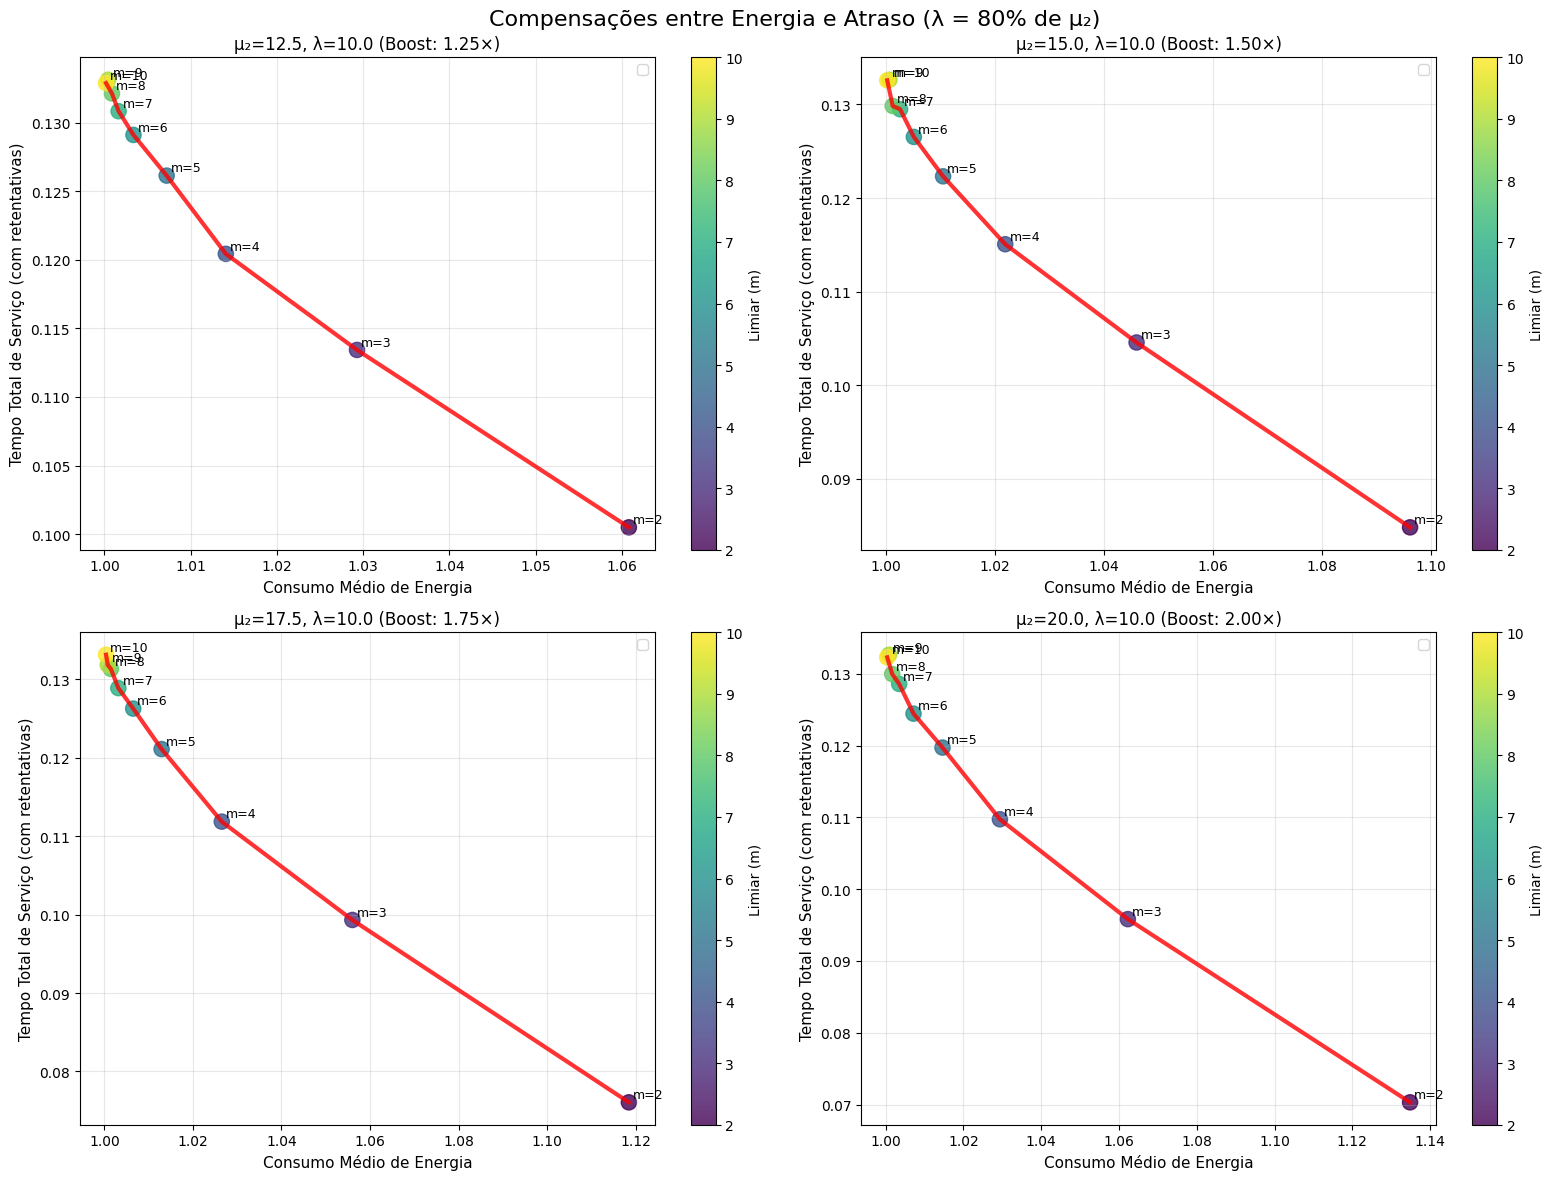

Running Optimal Threshold Analysis...
Análise de limiar ótimo: μ₂=12.5, λ=10.0
Análise de limiar ótimo: μ₂=15.0, λ=10.0
Análise de limiar ótimo: μ₂=17.5, λ=10.0
Análise de limiar ótimo: μ₂=20.0, λ=10.0


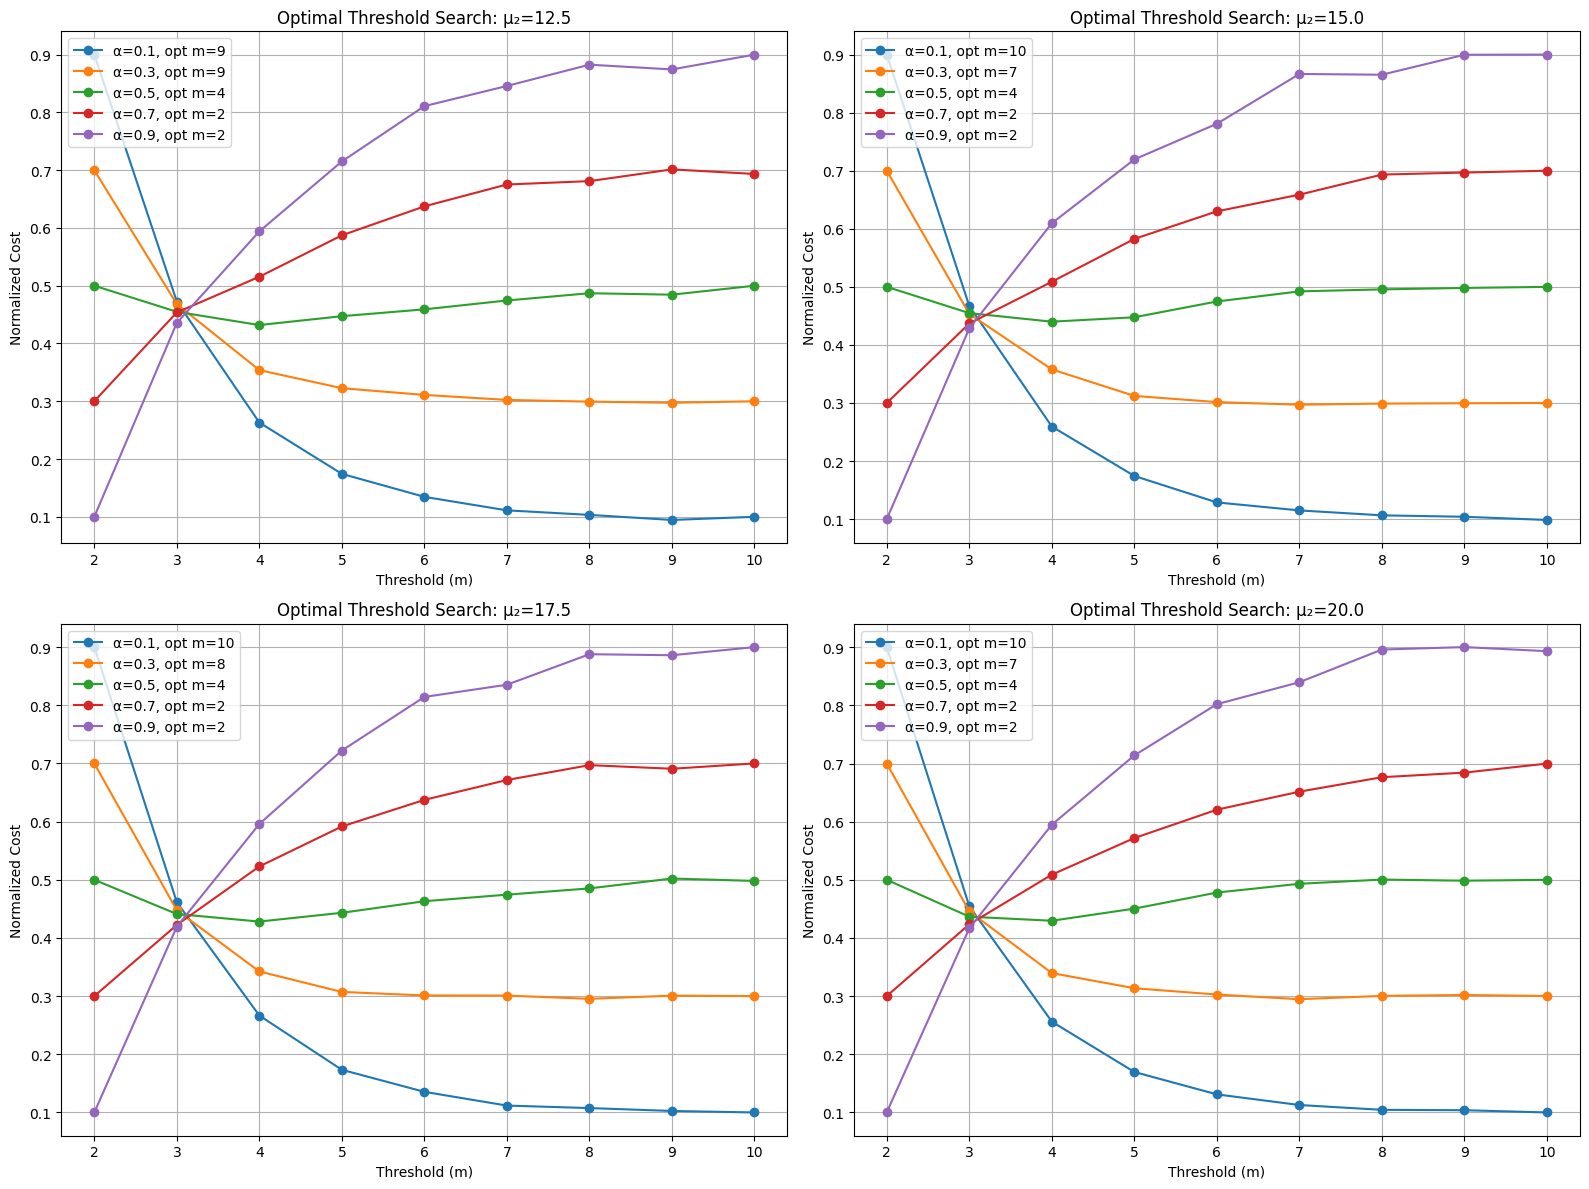

Running Sensitivity Analysis...


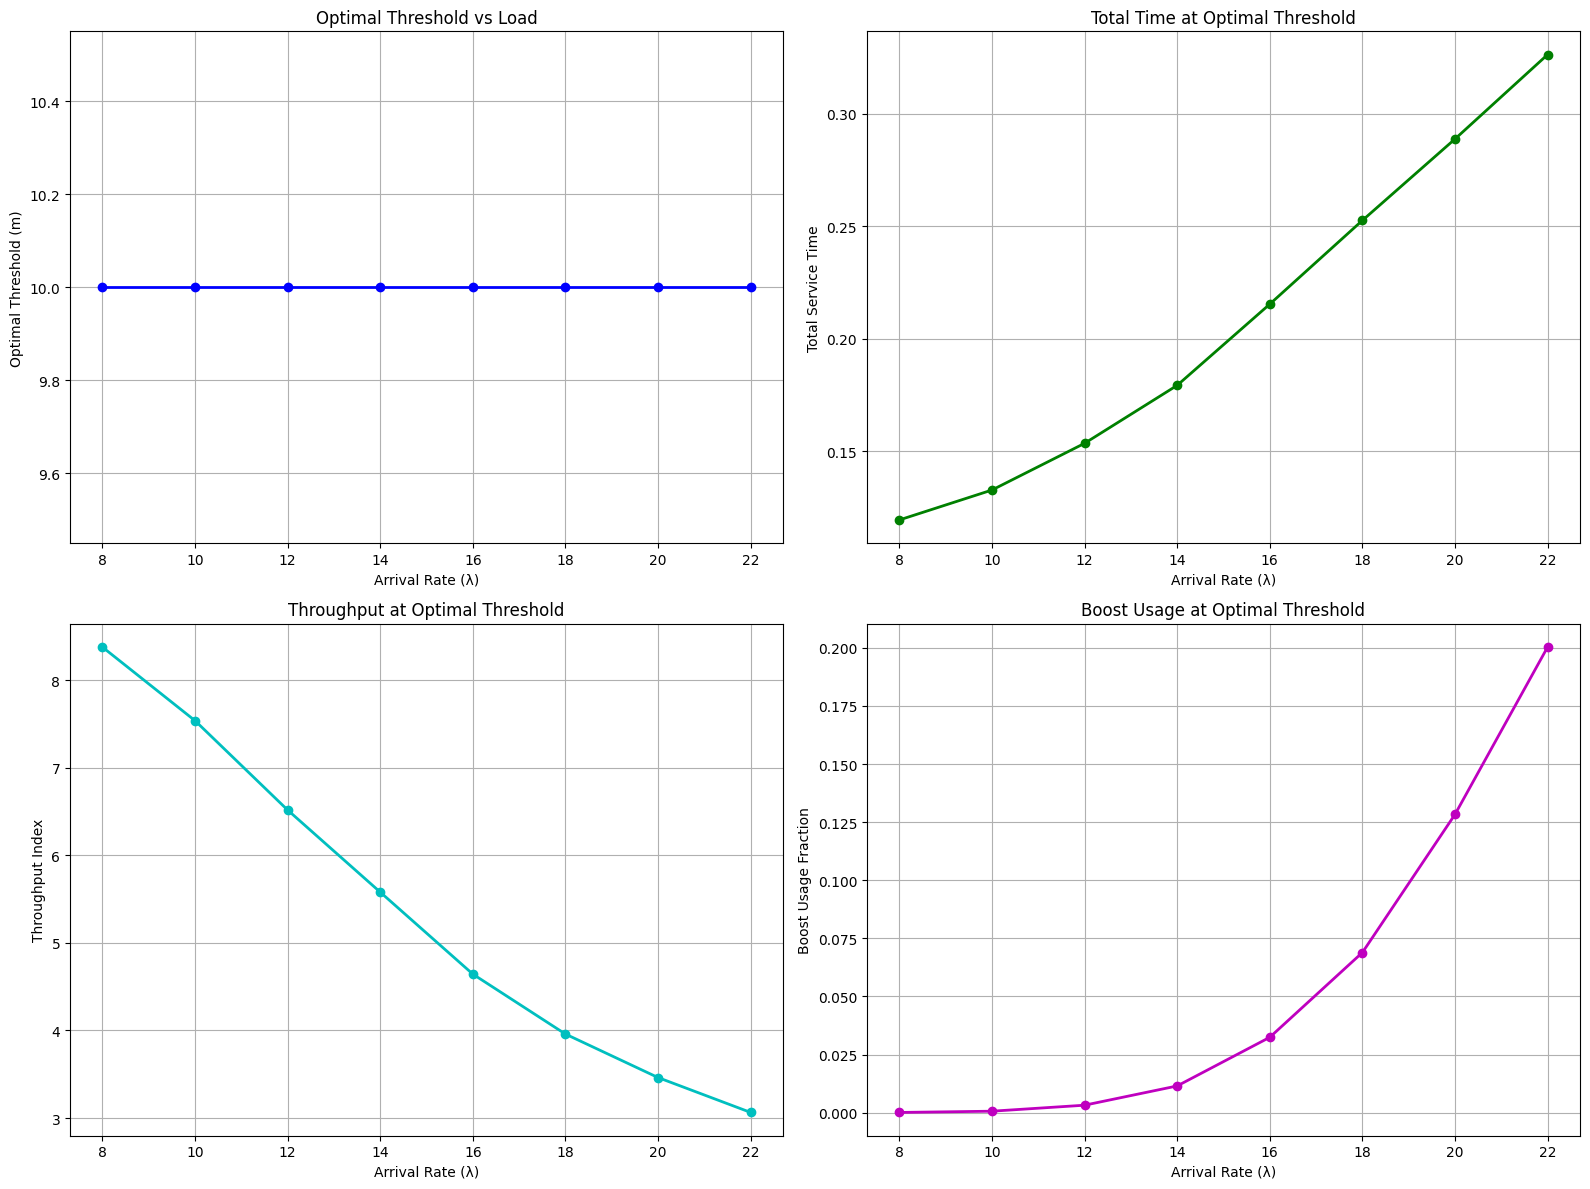

Analysis complete! Check the generated PNG files.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# Parâmetros fixos
J = 10                # Tamanho do buffer
mu_1 = 10.0           # Taxa de serviço base
N = 200000            # Número de chegadas para simular

# Parâmetros de análise
mu_2_ratios = [1.25, 1.5, 1.75, 2.0]  # Razões μ₂/μ₁
m_candidates = list(range(2, J+1))     # Candidatos de limiar (2 a 10)

# Definição dinâmica de lambda para cada razão de boost
# Antes: lambda_test = 15.0 (fixo)
# Agora: lambda é 80% da taxa de serviço aumentada
#lambda_tests = [2*mu_1 * ratio * 0.8 for ratio in mu_2_ratios]  # 80% de μ₂
lambda_tests = [10,10,10,10]  # 80% de μ₂

# Taxas de consumo de energia (unidades relativas) - CORRIGIDO
E1 = 1.0              # Energia por unidade de tempo em μ₁
E2_ratios = [1.25, 1.5, 1.75, 2.0]  # Deve corresponder aos mu_2_ratios

def calculate_power_consumption(t_mu1, t_mu2, E1, E2):
    """Calcula o consumo médio de energia"""
    total_time = t_mu1 + t_mu2
    if total_time > 0:
        return (t_mu1 * E1 + t_mu2 * E2) / total_time
    return E1

def calculate_total_service_time(avg_time, rej_prob):
    """Calcula o tempo total de serviço esperado incluindo retentativas"""
    # Se a probabilidade de rejeição for muito alta, limita o tempo esperado
    if rej_prob >= 0.99:
        return float('inf')
    return avg_time / (1 - rej_prob)

def calculate_throughput_index(avg_time, rej_prob):
    """Calcula o índice de vazão do serviço (quanto maior, melhor)"""
    # Evita divisão por zero
    if avg_time <= 0:
        return 0
    return (1 - rej_prob) / avg_time

def run_pareto_analysis():
    """Gera a fronteira de Pareto para tempo total de serviço vs consumo de energia"""

    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    plt.subplots_adjust(hspace=0.3, wspace=0.3)
    axs = axs.flatten()

    for idx, mu_ratio in enumerate(mu_2_ratios):
        mu_2 = mu_1 * mu_ratio
        E2 = E1 * E2_ratios[idx]
        lambda_test = lambda_tests[idx]  # Use o valor de lambda correspondente

        print(f"Analisando cenário {idx+1}: μ₂={mu_2:.1f}, λ={lambda_test:.1f} (80% de μ₂)")

        # Calcula métricas para cada limiar
        total_times = []
        powers = []
        thresholds = []

        for m in m_candidates:
            print(f"  m={m}...")
            avg_time, rej_prob, t_mu1, t_mu2 = run_adaptive_queue_simulation(
                J=J, m=m, lambda_val=lambda_test, mu_1=mu_1, mu_2=mu_2, N=N)

            # Calcula o tempo total de serviço (incluindo retentativas)
            total_time = calculate_total_service_time(avg_time, rej_prob)

            # Calcula o consumo de energia
            power = calculate_power_consumption(t_mu1, t_mu2, E1, E2)

            total_times.append(total_time)
            powers.append(power)
            thresholds.append(m)

        # Plota energia vs tempo total de serviço
        sc = axs[idx].scatter(powers, total_times, c=thresholds, cmap='viridis',
                             s=120, alpha=0.8)

        # Encontra e plota a fronteira de Pareto
        pareto_points = find_pareto_frontier(powers, total_times, thresholds)
        pareto_powers = [p[0] for p in pareto_points]
        pareto_times = [p[1] for p in pareto_points]
        pareto_ms = [p[2] for p in pareto_points]

        axs[idx].plot(pareto_powers, pareto_times, 'r-', linewidth=3,
                   alpha=0.8)

        # Adiciona rótulos para cada ponto
        for power, time, m in zip(powers, total_times, thresholds):
            axs[idx].annotate(f'm={m}', (power, time), xytext=(3, 3),
                            textcoords='offset points', fontsize=9)

        # Adiciona título e rótulos com informação de lambda
        axs[idx].set_title(f'μ₂={mu_2:.1f}, λ={lambda_test:.1f} (Boost: {mu_ratio:.2f}×)', fontsize=12)
        axs[idx].set_xlabel('Consumo Médio de Energia', fontsize=11)
        axs[idx].set_ylabel('Tempo Total de Serviço (com retentativas)', fontsize=11)
        axs[idx].grid(True, alpha=0.3)
        axs[idx].legend(fontsize=10)

        # Adiciona barra de cores
        cbar = plt.colorbar(sc, ax=axs[idx])
        cbar.set_label('Limiar (m)')

    plt.suptitle('Compensações entre Energia e Atraso (λ = 80% de μ₂)', fontsize=16)
    plt.tight_layout()
    plt.savefig('analise_tempo_total_servico.png', dpi=300)
    plt.show()

def find_pareto_frontier(powers, delays, thresholds):
    """Encontra pontos na fronteira de Pareto (minimiza energia e atraso)"""
    points = list(zip(powers, delays, thresholds))
    pareto_points = []

    for i, (p1, d1, m1) in enumerate(points):
        is_pareto = True
        for j, (p2, d2, m2) in enumerate(points):
            if i != j:
                # Ponto é dominado se outro ponto é melhor em ambas dimensões
                if p2 <= p1 and d2 <= d1 and (p2 < p1 or d2 < d1):
                    is_pareto = False
                    break
        if is_pareto:
            pareto_points.append((p1, d1, m1))

    # Ordena pelo consumo de energia para plotagem
    pareto_points.sort(key=lambda x: x[0])
    return pareto_points

def find_optimal_threshold(alpha=0.5):
    """Encontra o limiar ótimo usando função de custo ponderada com tempo total de serviço"""

    plt.figure(figsize=(16, 12))

    for idx, mu_ratio in enumerate(mu_2_ratios):
        mu_2 = mu_1 * mu_ratio
        E2 = E1 * E2_ratios[idx]
        lambda_test = lambda_tests[idx]  # Use o valor de lambda correspondente

        print(f"Análise de limiar ótimo: μ₂={mu_2:.1f}, λ={lambda_test:.1f}")

        plt.subplot(2, 2, idx+1)

        # Grid search over different alpha values
        alpha_values = [0.1, 0.3, 0.5, 0.7, 0.9]

        for alpha in alpha_values:
            costs = []
            total_times = []
            powers = []

            for m in m_candidates:
                avg_time, rej_prob, t_mu1, t_mu2 = run_adaptive_queue_simulation(
                    J=J, m=m, lambda_val=lambda_tests[idx], mu_1=mu_1, mu_2=mu_2, N=N)

                # Use total service time instead of effective delay
                total_time = calculate_total_service_time(avg_time, rej_prob)
                power = calculate_power_consumption(t_mu1, t_mu2, E1, E2)

                total_times.append(total_time)
                powers.append(power)

            # Normalize after collecting all data
            max_time = max(total_times)
            min_time = min(total_times)
            max_power = max(powers)
            min_power = min(powers)

            normalized_costs = []
            for time, power in zip(total_times, powers):
                # Handle case where all times or powers are the same
                norm_time = (time - min_time) / (max_time - min_time) if max_time > min_time else 0
                norm_power = (power - min_power) / (max_power - min_power) if max_power > min_power else 0
                cost = alpha * norm_time + (1 - alpha) * norm_power
                normalized_costs.append(cost)

            # Find optimal threshold
            optimal_idx = np.argmin(normalized_costs)
            optimal_m = m_candidates[optimal_idx]

            plt.plot(m_candidates, normalized_costs, 'o-',
                    label=f'α={alpha:.1f}, opt m={optimal_m}')

        plt.xlabel('Threshold (m)')
        plt.ylabel('Normalized Cost')
        plt.title(f'Optimal Threshold Search: μ₂={mu_2:.1f}')
        plt.grid(True)
        plt.legend()

    plt.tight_layout()
    plt.savefig('total_time_optimal_threshold.png', dpi=300)
    plt.show()

def sensitivity_analysis():
    """Analyze sensitivity to arrival rate"""

    lambda_range = np.linspace(8, 22, 8)
    mu_2 = mu_1 * 1.5  # Fixed boost ratio
    E2 = E1 * 2.0      # Fixed energy ratio

    plt.figure(figsize=(16, 12))

    # Plot 1: Optimal threshold vs arrival rate (remains unchanged)
    plt.subplot(2, 2, 1)
    optimal_thresholds = []

    for lambda_val in lambda_range:
        costs = []
        for m in m_candidates:
            avg_time, rej_prob, t_mu1, t_mu2 = run_adaptive_queue_simulation(
                J=J, m=m, lambda_val=lambda_val, mu_1=mu_1, mu_2=mu_2, N=N)

            # Use total service time instead of penalty-based delay
            total_time = calculate_total_service_time(avg_time, rej_prob)
            power = calculate_power_consumption(t_mu1, t_mu2, E1, E2)

            # Weighted cost (α = 0.5)
            # Normalize metrics to avoid scale issues
            norm_time = min(total_time / 10.0, 1.0)  # Cap at 1.0
            norm_power = power / E2
            cost = 0.5 * norm_time + 0.5 * norm_power
            costs.append(cost)

        optimal_m = m_candidates[np.argmin(costs)]
        optimal_thresholds.append(optimal_m)

    plt.plot(lambda_range, optimal_thresholds, 'bo-', linewidth=2)
    plt.xlabel('Arrival Rate (λ)')
    plt.ylabel('Optimal Threshold (m)')
    plt.title('Optimal Threshold vs Load')
    plt.grid(True)

    # Collect metrics at optimal thresholds
    total_times_opt = []
    throughputs_opt = []
    powers_opt = []
    boost_fractions_opt = []

    for lambda_val, m_opt in zip(lambda_range, optimal_thresholds):
        avg_time, rej_prob, t_mu1, t_mu2 = run_adaptive_queue_simulation(
            J=J, m=m_opt, lambda_val=lambda_val, mu_1=mu_1, mu_2=mu_2, N=N)

        total_time = calculate_total_service_time(avg_time, rej_prob)
        throughput = calculate_throughput_index(avg_time, rej_prob)
        power = calculate_power_consumption(t_mu1, t_mu2, E1, E2)
        boost_frac = t_mu2 / (t_mu1 + t_mu2) if (t_mu1 + t_mu2) > 0 else 0

        total_times_opt.append(total_time)
        throughputs_opt.append(throughput)
        powers_opt.append(power)
        boost_fractions_opt.append(boost_frac)

    # Plot 2: Total Service Time at optimal threshold
    plt.subplot(2, 2, 2)
    plt.plot(lambda_range, total_times_opt, 'go-', linewidth=2)
    plt.xlabel('Arrival Rate (λ)')
    plt.ylabel('Total Service Time')
    plt.title('Total Time at Optimal Threshold')
    plt.grid(True)

    # Plot 3: Throughput at optimal threshold
    plt.subplot(2, 2, 3)
    plt.plot(lambda_range, throughputs_opt, 'co-', linewidth=2)
    plt.xlabel('Arrival Rate (λ)')
    plt.ylabel('Throughput Index')
    plt.title('Throughput at Optimal Threshold')
    plt.grid(True)

    # Plot 4: Boost Usage at optimal threshold
    plt.subplot(2, 2, 4)
    plt.plot(lambda_range, boost_fractions_opt, 'mo-', linewidth=2)
    plt.xlabel('Arrival Rate (λ)')
    plt.ylabel('Boost Usage Fraction')
    plt.title('Boost Usage at Optimal Threshold')
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('sensitivity_analysis_new_metrics.png')
    plt.show()

# Run all analyses
if __name__ == "__main__":
    print("Running Pareto Frontier Analysis...")
    run_pareto_analysis()

    print("Running Optimal Threshold Analysis...")
    results = find_optimal_threshold()

    print("Running Sensitivity Analysis...")
    sensitivity_analysis()

    print("Analysis complete! Check the generated PNG files.")


Analisando buffer J=10, limiar m=5
  Simulando λ=10.0...
  Simulando λ=10.0 (apenas μ₂)...
  Simulando λ=15.0...
  Simulando λ=15.0 (apenas μ₂)...
  Simulando λ=20.0...
  Simulando λ=20.0 (apenas μ₂)...
  Simulando λ=25.0...
  Simulando λ=25.0 (apenas μ₂)...
  Simulando λ=30.0...
  Simulando λ=30.0 (apenas μ₂)...
  Simulando λ=35.0...
  Simulando λ=35.0 (apenas μ₂)...
  Simulando λ=40.0...
  Simulando λ=40.0 (apenas μ₂)...
  Simulando λ=45.0...
  Simulando λ=45.0 (apenas μ₂)...

Analisando buffer J=20, limiar m=10
  Simulando λ=10.0...
  Simulando λ=10.0 (apenas μ₂)...
  Simulando λ=15.0...
  Simulando λ=15.0 (apenas μ₂)...
  Simulando λ=20.0...
  Simulando λ=20.0 (apenas μ₂)...
  Simulando λ=25.0...
  Simulando λ=25.0 (apenas μ₂)...
  Simulando λ=30.0...
  Simulando λ=30.0 (apenas μ₂)...
  Simulando λ=35.0...
  Simulando λ=35.0 (apenas μ₂)...
  Simulando λ=40.0...
  Simulando λ=40.0 (apenas μ₂)...
  Simulando λ=45.0...
  Simulando λ=45.0 (apenas μ₂)...

Analisando buffer J=30, limiar

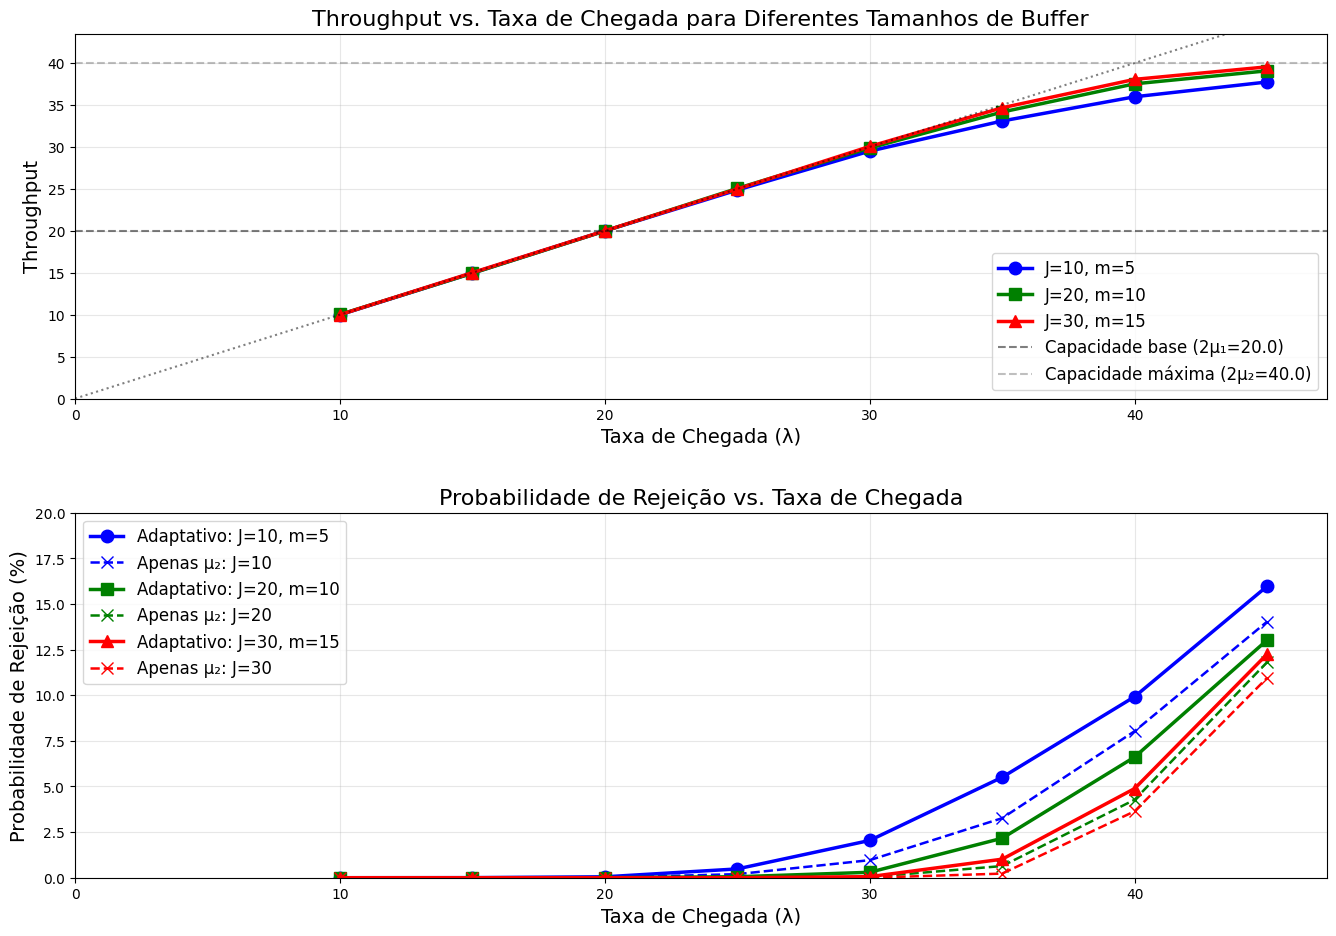


Comparação de Probabilidade de Rejeição (%): Adaptativo vs. Apenas μ₂
Lambda	J=10	J=20	J=30	μ₂ J=10	μ₂ J=20	μ₂ J=30
10.0	0.00	0.00	0.00	0.00	0.00	0.00
15.0	0.00	0.00	0.00	0.00	0.00	0.00
20.0	0.05	0.01	0.00	0.01	0.00	0.00
25.0	0.48	0.05	0.00	0.19	0.00	0.00
30.0	2.04	0.30	0.06	0.96	0.04	0.00
35.0	5.51	2.16	1.02	3.26	0.64	0.23
40.0	9.92	6.61	4.89	8.03	4.28	3.64
45.0	15.97	13.02	12.25	14.04	11.82	10.95


In [19]:
# Parâmetros fixos
mu_1 = 10.0
mu_2 = 20.0
N = 100000

# Parâmetros de variação
J_values = [10, 20, 30]  # Tamanhos de buffer a testar
lambda_range = np.linspace(10, 45, 8)  # Taxas de chegada de 10 a 45

# Armazenamento para resultados
throughputs = {J: [] for J in J_values}
rejection_probs = {J: [] for J in J_values}
rejection_probs_only_mu2 = {J: [] for J in J_values}  # Novo: para caso apenas μ₂

# Cores para cada tamanho de buffer
colors = ['blue', 'green', 'red']
markers = ['o', 's', '^']

# Executar simulações
for i, J in enumerate(J_values):
    m = int(0.5 * J)  # Definir m como metade de J
    print(f"\nAnalisando buffer J={J}, limiar m={m}")

    for lambda_val in lambda_range:
        print(f"  Simulando λ={lambda_val:.1f}...")

        # Executar simulação com adaptação
        results = run_adaptive_queue_simulations(
            J=J, m=m, lambda_val=lambda_val, mu_1=mu_1, mu_2=mu_2, N=N)

        # Extrair métricas de interesse
        _, rej_prob, _, _, throughput, _, _, _ = results

        # Armazenar resultados
        throughputs[J].append(throughput)
        rejection_probs[J].append(rej_prob)

        # Executar simulação apenas com μ₂
        print(f"  Simulando λ={lambda_val:.1f} (apenas μ₂)...")
        results_only_mu2 = run_adaptive_queue_simulations(
            J=J, m=0, lambda_val=lambda_val, mu_1=mu_2, mu_2=mu_2, N=N)  # m=0 e mu_1=mu_2 força uso apenas de μ₂

        # Extrair probabilidade de rejeição
        _, rej_prob_only_mu2, _, _, _, _, _, _ = results_only_mu2

        # Armazenar resultado
        rejection_probs_only_mu2[J].append(rej_prob_only_mu2)

# Criar figura com dois subplots
plt.figure(figsize=(14, 10))

# Subplot 1: Throughput
plt.subplot(2, 1, 1)
for i, J in enumerate(J_values):
    m = int(0.5 * J)
    plt.plot(lambda_range, throughputs[J], '-', color=colors[i],
             marker=markers[i], markersize=9, linewidth=2.5,
             label=f'J={J}, m={m}')

# Adicionar linha de referência y=x (throughput ideal)
plt.plot([0, max(lambda_range)], [0, max(lambda_range)], 'k:', alpha=0.5)

# Adicionar linhas de capacidade teórica
plt.axhline(y=2*mu_1, color='black', linestyle='--', alpha=0.5,
          label=f'Capacidade base (2μ₁={2*mu_1})')
plt.axhline(y=2*mu_2, color='gray', linestyle='--', alpha=0.5,
          label=f'Capacidade máxima (2μ₂={2*mu_2})')

plt.xlabel('Taxa de Chegada (λ)', fontsize=14)
plt.ylabel('Throughput', fontsize=14)
plt.title('Throughput vs. Taxa de Chegada para Diferentes Tamanhos de Buffer', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, loc='best')
plt.xlim(0, max(lambda_range) * 1.05)
plt.ylim(0, max(max(throughputs[J]) for J in J_values) * 1.1)

# Subplot 2: Probabilidade de Rejeição - LIMITAR A 20%
plt.subplot(2, 1, 2)
for i, J in enumerate(J_values):
    m = int(0.5 * J)
    # Plotar caso adaptativo
    plt.plot(lambda_range, [p*100 for p in rejection_probs[J]], '-', color=colors[i],
             marker=markers[i], markersize=9, linewidth=2.5,
             label=f'Adaptativo: J={J}, m={m}')

    # Plotar caso apenas μ₂
    plt.plot(lambda_range, [p*100 for p in rejection_probs_only_mu2[J]], '--', color=colors[i],
             marker='x', markersize=8, linewidth=1.8,
             label=f'Apenas μ₂: J={J}')

plt.xlabel('Taxa de Chegada (λ)', fontsize=14)
plt.ylabel('Probabilidade de Rejeição (%)', fontsize=14)
plt.title('Probabilidade de Rejeição vs. Taxa de Chegada', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, loc='best')
plt.xlim(0, max(lambda_range) * 1.05)
plt.ylim(0, 20)  # Limitado a 20% para melhor visualização

# Melhorar a aparência geral
plt.tight_layout(pad=3.0)
plt.savefig('analise_tamanho_buffer_comparacao.png', dpi=300)
plt.show()

# Imprimir tabela comparativa
print("\nComparação de Probabilidade de Rejeição (%): Adaptativo vs. Apenas μ₂")
print("Lambda\t" + "\t".join([f"J={J}" for J in J_values]) + "\t" + "\t".join([f"μ₂ J={J}" for J in J_values]))

for i, lambda_val in enumerate(lambda_range):
    values_adaptive = [rejection_probs[J][i]*100 for J in J_values]
    values_only_mu2 = [rejection_probs_only_mu2[J][i]*100 for J in J_values]

    all_values = []
    for j in range(len(J_values)):
        all_values.append(f"{values_adaptive[j]:.2f}")

    for j in range(len(J_values)):
        all_values.append(f"{values_only_mu2[j]:.2f}")

    print(f"{lambda_val:.1f}\t" + "\t".join(all_values))